# Lesson 16 — Comparing many groups: ANOVA

*Part 2 · Lesson 16 of 20  ·  data: Palmer Penguins*

**←** [Lesson 15: t-tests: one-sample, two-sample & paired](15-t-tests.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 17: Chi-square: goodness-of-fit & independence](17-chi-square.ipynb) **→**

**Same idea, another way:**  [Another dataset →](16-anova~another-dataset.ipynb)  ·  [The code behind it →](16-anova~the-code.ipynb)

You already know how to compare **two** group means with a t-test. But what if you have **three**
groups — or ten? The tempting move is to t-test every pair. That turns out to be a trap: the more
comparisons you run, the more likely you are to "find" a difference that **isn't real**. We'll *show*
that trap by simulation, then meet the one test that sidesteps it — the **one-way ANOVA** and its
**F-statistic** — and finish by asking the natural follow-up: *which* groups actually differ?

Our data is the **Palmer Penguins** again: **body mass** across the three species (Adelie, Chinstrap,
Gentoo). Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats        # f_oneway, ttest_ind, f-distribution
sl.use_course_style()

PENGUINS_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = sl.load_csv('penguins.csv', url=PENGUINS_URL)

# Keep rows that have the two columns we'll use.
penguins = penguins.dropna(subset=['body_mass_g', 'species'])
species_order = ['Adelie', 'Chinstrap', 'Gentoo']

print(f'{len(penguins)} penguins across {penguins["species"].nunique()} species')
penguins.groupby('species')['body_mass_g'].agg(['count', 'mean', 'std']).round(1)

342 penguins across 3 species


,count,mean,std
species,,,
Adelie,151,3700.7,458.6
Chinstrap,68,3733.1,384.3
Gentoo,123,5076.0,504.1


## 1) The question, and the wrong way to answer it

We want to know: **does mean body mass differ among the three species?** The three sample means above
are clearly not identical — Gentoo look much heavier — but sample means *always* differ a little just
by luck. The real question is whether the differences are **bigger than sampling noise**.

Your first instinct, fresh from the t-tests lesson, is probably to run a t-test on each **pair**:
Adelie vs Chinstrap, Adelie vs Gentoo, Chinstrap vs Gentoo. With three groups that's 3 tests. With
$k$ groups it's $\binom{k}{2} = k(k-1)/2$ tests, which grows fast — 10 groups would mean 45 tests.

The problem is hiding in the word **"significant."** Each t-test at $\alpha = 0.05$ has a **5% chance
of a false alarm** (a "significant" result when there's truly no difference — a **Type I error**).
Run many tests and those 5%-chances *accumulate*. Let's measure exactly how badly.

## 2) The multiple-comparisons problem — *seen*, not just stated

Here is the cleanest possible demonstration. We'll build a world where **there is no real difference
at all**: every "group" is drawn from the *same* normal distribution. Then we run all the pairwise
t-tests and ask: *did at least one of them cry "significant" by accident?*

That "at least one false alarm" event is the **family-wise error rate** (FWER) — the chance the whole
*family* of tests produces one or more false positives. If each test were the only one, it'd be 5%.
Watch what happens when there are several.

In [2]:
rng = np.random.default_rng(0)   # change this seed to re-roll the whole experiment

def family_has_false_alarm(k_groups, n_per_group=30, alpha=0.05):
    '''Draw k groups from the SAME distribution (no real difference),
       run every pairwise t-test, and report whether ANY came out "significant".'''
    groups = [rng.normal(0, 1, size=n_per_group) for _ in range(k_groups)]
    for i in range(k_groups):
        for j in range(i + 1, k_groups):
            if stats.ttest_ind(groups[i], groups[j]).pvalue < alpha:
                return True          # a false positive — there was NO real difference
    return False

# How often does the FAMILY of tests fire at least one false alarm?
TRIALS = 4000
for k in [2, 3, 5, 10]:
    n_pairs = k * (k - 1) // 2
    fwer = np.mean([family_has_false_alarm(k) for _ in range(TRIALS)])
    print(f'{k:>2} groups ({n_pairs:>2} pairwise tests):  '
          f'family-wise false-alarm rate = {fwer*100:4.1f}%   (each single test is only 5%)')

 2 groups ( 1 pairwise tests):  family-wise false-alarm rate =  5.3%   (each single test is only 5%)


 3 groups ( 3 pairwise tests):  family-wise false-alarm rate = 11.7%   (each single test is only 5%)


 5 groups (10 pairwise tests):  family-wise false-alarm rate = 28.9%   (each single test is only 5%)


10 groups (45 pairwise tests):  family-wise false-alarm rate = 61.3%   (each single test is only 5%)


Read those numbers slowly. With **2** groups (1 test) the false-alarm rate is the promised ~5%. But
with **5** groups it's already around **30%**, and with **10** groups it's roughly **60%** — even
though, by construction, **nothing is different**. If you go fishing through enough pairs, you are
*more likely than not* to "discover" a difference that is pure noise.

A handy back-of-the-envelope formula: if you run $m$ **independent** tests each at $\alpha$, the chance
of **no** false alarm is $(1-\alpha)^m$, so

$$\text{FWER} \le 1 - (1-\alpha)^{m}.$$

But our pairwise tests are *not* independent — they share groups (Adelie-vs-Gentoo and
Chinstrap-vs-Gentoo both reuse the Gentoo sample), and that sharing makes them **positively
correlated**. Correlated tests fail together more and succeed together more, so the family produces
*fewer* fresh false alarms than $m$ independent tests would. The formula is therefore an **upper bound
/ heuristic** — the true FWER rises with the number of comparisons, but sits **below** the curve. Let's
overlay the two and see exactly how far below.

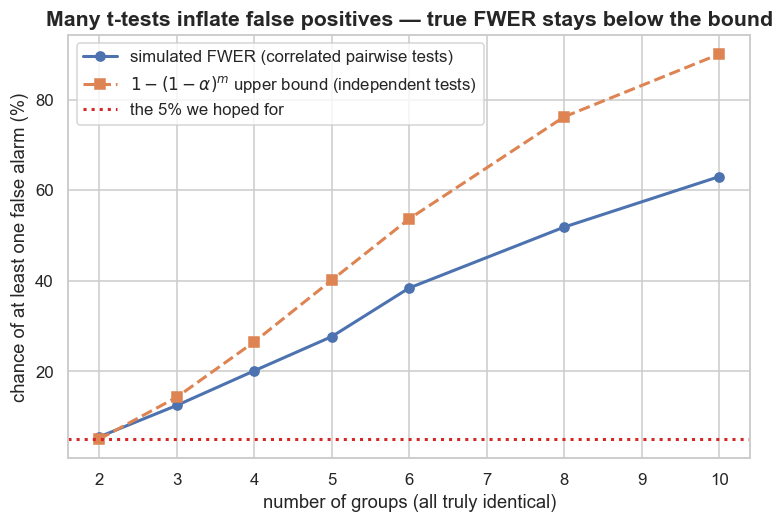

At every k, the simulated (correlated) FWER sits BELOW the independent-tests formula.


In [3]:
ks = np.array([2, 3, 4, 5, 6, 8, 10])
n_pairs = ks * (ks - 1) // 2
sim = np.array([np.mean([family_has_false_alarm(int(k)) for _ in range(2000)]) for k in ks])
formula = 1 - (1 - 0.05) ** n_pairs

fig, ax = plt.subplots()
ax.plot(ks, sim * 100, 'o-', color='#4c72b0', lw=2, label='simulated FWER (correlated pairwise tests)')
ax.plot(ks, formula * 100, 's--', color='#dd8452', lw=2,
        label=r'$1-(1-\alpha)^{m}$ upper bound (independent tests)')
ax.axhline(5, color='#d62728', ls=':', lw=2, label='the 5% we hoped for')
ax.set_xlabel('number of groups (all truly identical)')
ax.set_ylabel('chance of at least one false alarm (%)')
ax.set_title('Many t-tests inflate false positives — true FWER stays below the bound')
ax.legend(); plt.show()
print('At every k, the simulated (correlated) FWER sits BELOW the independent-tests formula.')

This is *why* we don't just spray t-tests across every pair. We need a **single** test that asks one
honest question — "is **any** group different?" — at one controlled error rate of 5%. That test is the
**one-way ANOVA**.

## 3) The idea behind ANOVA: split the variation in two

**ANOVA** stands for **AN**alysis **O**f **VA**riance. The name sounds odd — we're comparing *means*,
so why analyze *variance*? The trick is that we can answer "do the means differ?" by comparing **two
kinds of spread**:

- **Between-group variation** — how far each *group mean* sits from the *overall* (grand) mean. If the
  species really differ, the group means are spread far apart, so this is **large**.
- **Within-group variation** — how much penguins *wobble around their own group's mean*. This is the
  natural, irreducible noise inside each species, regardless of whether the species differ.

The whole test is the **ratio** of these two:

$$F = \frac{\text{between-group variation (per group)}}{\text{within-group variation (per penguin)}}
     = \frac{MS_{\text{between}}}{MS_{\text{within}}}.$$

- **Big $F$** (well above 1): the gaps between group means dwarf the noise inside groups → the means
  really do differ.
- **$F$ near 1**: the group means are no further apart than you'd expect from within-group noise alone
  → no evidence of a real difference.

The hypotheses are:

- $H_0$: all group means are equal, $\mu_{\text{Adelie}} = \mu_{\text{Chinstrap}} = \mu_{\text{Gentoo}}$.
- $H_a$: **at least one** mean differs from the others. (Note: $H_a$ does *not* say which one — that's
  the follow-up question in section 6.)

### The math, term by term

Let there be $k$ groups, group $j$ having $n_j$ observations with mean $\bar{x}_j$, and let $\bar{x}$
be the grand mean of all $N$ observations. We add up squared distances ("sums of squares"):

$$SS_{\text{between}} = \sum_{j=1}^{k} n_j(\bar{x}_j - \bar{x})^2,
  \qquad
  SS_{\text{within}} = \sum_{j=1}^{k} \sum_{i=1}^{n_j} (x_{ij} - \bar{x}_j)^2.$$

Each sum of squares is turned into a **mean square** by dividing by its **degrees of freedom** (df) —
a count of how many values were free to vary:

$$MS_{\text{between}} = \frac{SS_{\text{between}}}{k - 1},
  \qquad
  MS_{\text{within}} = \frac{SS_{\text{within}}}{N - k},
  \qquad
  F = \frac{MS_{\text{between}}}{MS_{\text{within}}}.$$

Let's compute every one of these by hand on the penguins, so the $F$ that scipy hands back is no
mystery.

In [4]:
groups = [penguins.loc[penguins['species'] == s, 'body_mass_g'].to_numpy() for s in species_order]
all_mass = penguins['body_mass_g'].to_numpy()

grand_mean = all_mass.mean()
N = len(all_mass)
k = len(groups)

# Between-group: each group's mean vs the grand mean, weighted by group size.
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
# Within-group: each penguin vs its OWN group's mean.
ss_within  = sum(((g - g.mean()) ** 2).sum() for g in groups)

df_between = k - 1
df_within  = N - k
ms_between = ss_between / df_between
ms_within  = ss_within / df_within
F_hand = ms_between / ms_within

print(f'grand mean = {grand_mean:.1f} g over N = {N} penguins in k = {k} groups\n')
print(f'SS_between = {ss_between:14,.0f}   df = {df_between:>4}   MS_between = {ms_between:12,.0f}')
print(f'SS_within  = {ss_within:14,.0f}   df = {df_within:>4}   MS_within  = {ms_within:12,.0f}')
print(f'\nF = MS_between / MS_within = {ms_between:,.0f} / {ms_within:,.0f} = {F_hand:.2f}')

grand mean = 4201.8 g over N = 342 penguins in k = 3 groups

SS_between =    146,864,214   df =    2   MS_between =   73,432,107
SS_within  =     72,443,483   df =  339   MS_within  =      213,698

F = MS_between / MS_within = 73,432,107 / 213,698 = 343.63


An $F$ of about **343** is enormous — the spread *between* the species means is hundreds of times
larger than the wobble *within* a species. Now let's confirm scipy computes the exact same number, and
get the p-value.

In [5]:
F, p = stats.f_oneway(*groups)
print(f'scipy.stats.f_oneway:  F = {F:.2f},  p = {p:.2e}')
print(f'our by-hand F        :  F = {F_hand:.2f}')
print('\nThey match — scipy is just doing the sums-of-squares bookkeeping for us.')
print(f'\np = {p:.2e} is astronomically small, so we REJECT H0:')
print('at least one species has a different mean body mass. (No surprise — look at Gentoo.)')

scipy.stats.f_oneway:  F = 343.63,  p = 2.89e-82
our by-hand F        :  F = 343.63

They match — scipy is just doing the sums-of-squares bookkeeping for us.

p = 2.89e-82 is astronomically small, so we REJECT H0:
at least one species has a different mean body mass. (No surprise — look at Gentoo.)


## 4) Where does the F-distribution come from?

The p-value answers: *if all species truly had the same mean (H0), how often would random sampling
hand us an $F$ this large or larger?* The reference curve is the **F-distribution**, which has **two**
degrees-of-freedom parameters — $df_{\text{between}} = k-1$ on top and $df_{\text{within}} = N-k$ on
the bottom.

Rather than take that distribution on faith, let's **build the null world by simulation**, exactly as
the hypothesis-testing lesson taught. We **shuffle** the species labels so they no longer line up with
any real mass difference, recompute $F$, and repeat thousands of times. That pile of "$F$ under $H_0$"
values *is* the F-distribution — and the fraction beyond our observed $F$ *is* the p-value.

In [6]:
labels = penguins['species'].to_numpy()
mass = penguins['body_mass_g'].to_numpy()

def f_stat(values, labs):
    gs = [values[labs == s] for s in species_order]
    return stats.f_oneway(*gs).statistic

# Permutation null: break the link between species and mass by shuffling labels.
n_perm = 5000
null_F = np.empty(n_perm)
shuffled = labels.copy()
for i in range(n_perm):
    rng.shuffle(shuffled)
    null_F[i] = f_stat(mass, shuffled)

perm_p = (np.sum(null_F >= F) + 1) / (n_perm + 1)   # +1 so the p-value is never exactly 0
print(f'Observed F (real labels) = {F:.1f}')
print(f'Largest F in {n_perm} shuffled (null) worlds = {null_F.max():.2f}')
print(f'Permutation p-value = {perm_p:.4f}   (none of the fake worlds came anywhere close)')

Observed F (real labels) = 343.6
Largest F in 5000 shuffled (null) worlds = 12.98
Permutation p-value = 0.0002   (none of the fake worlds came anywhere close)


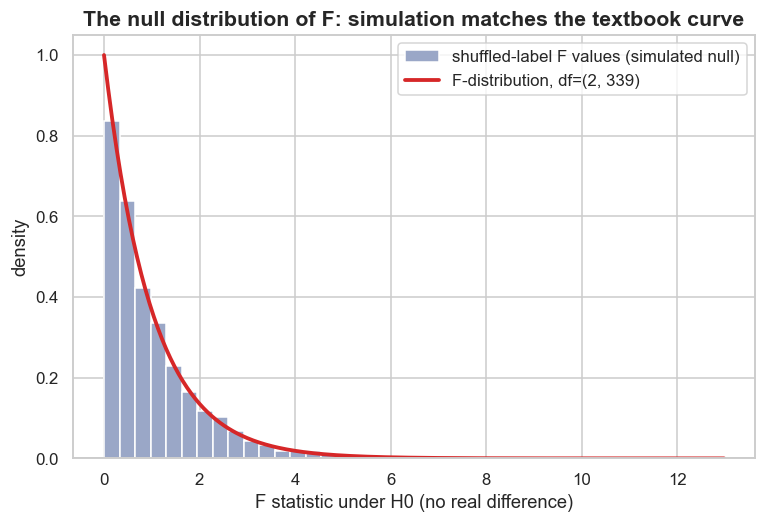

Our observed F = 344 is FAR to the right of everything here — off the chart.


In [7]:
# Compare the simulated null to the textbook F-distribution curve — they should agree.
fig, ax = plt.subplots()
ax.hist(null_F, bins=40, density=True, color='#9aa7c7', edgecolor='white',
        label='shuffled-label F values (simulated null)')
xs = np.linspace(0, max(6, null_F.max()), 300)
ax.plot(xs, stats.f.pdf(xs, df_between, df_within), color='#d62728', lw=2.5,
        label=f'F-distribution, df=({df_between}, {df_within})')
ax.set_xlabel('F statistic under H0 (no real difference)')
ax.set_ylabel('density')
ax.set_title('The null distribution of F: simulation matches the textbook curve')
ax.legend(); plt.show()
print(f'Our observed F = {F:.0f} is FAR to the right of everything here — off the chart.')

The histogram of shuffled-label $F$ values lands right under the red textbook F-curve — that's why we
can trust the formula's p-value. And our real $F \approx 343$ is so far off the right edge of this
plot that no shuffled world ever produced anything like it. That tiny p-value is the omnibus test
shouting: **the species are not all the same.**

### See it: group means and a boxplot

A picture makes the same point your $F$-statistic does. The spread of the *colored group means* (the
between-group signal) is huge compared with the *height of each box* (the within-group noise).

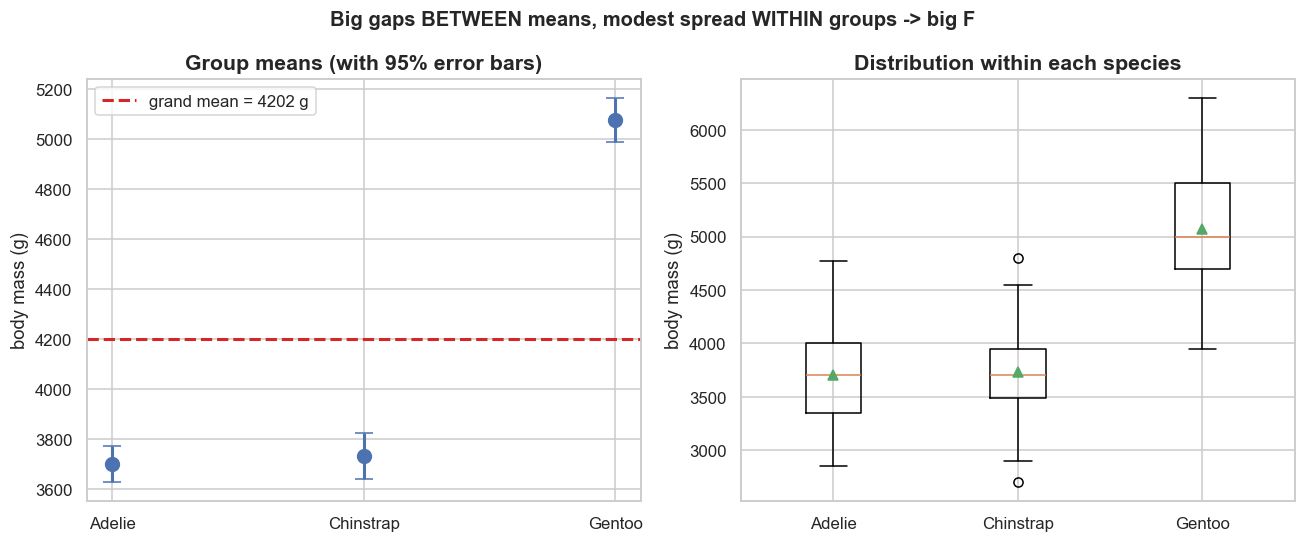

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))
colors = {'Adelie': '#4c72b0', 'Chinstrap': '#dd8452', 'Gentoo': '#2ca02c'}

# LEFT: each group's mean (the between-group spread), against the grand mean.
means = [g.mean() for g in groups]
sems  = [g.std(ddof=1) / np.sqrt(len(g)) for g in groups]   # std error of each mean
axL.errorbar(species_order, means, yerr=[1.96 * s for s in sems], fmt='o', ms=9,
             capsize=6, lw=2, color='#4c72b0')
axL.axhline(grand_mean, color='#d62728', ls='--', lw=2, label=f'grand mean = {grand_mean:.0f} g')
axL.set_ylabel('body mass (g)'); axL.set_title('Group means (with 95% error bars)')
axL.legend()

# RIGHT: the full distributions — box height shows within-group spread.
axR.boxplot(groups, tick_labels=species_order, showmeans=True)
axR.set_ylabel('body mass (g)'); axR.set_title('Distribution within each species')

fig.suptitle('Big gaps BETWEEN means, modest spread WITHIN groups -> big F', fontweight='bold')
plt.tight_layout(); plt.show()

## 5) Sanity check: ANOVA with two groups *is* the two-sample t-test

ANOVA generalizes the two-sample t-test you already know. In fact, with exactly **two** groups they
are the *same test*, related by a clean identity: $F = t^2$, and the two p-values are identical. Let's
prove it on Adelie vs Chinstrap.

In [9]:
adelie = penguins.loc[penguins['species'] == 'Adelie', 'body_mass_g']
chinstrap = penguins.loc[penguins['species'] == 'Chinstrap', 'body_mass_g']

t_res = stats.ttest_ind(adelie, chinstrap)          # the classic two-sample t-test
f_res = stats.f_oneway(adelie, chinstrap)           # ANOVA on the SAME two groups

print(f'two-sample t-test:  t = {t_res.statistic:+.4f},  p = {t_res.pvalue:.4f}')
print(f'one-way ANOVA    :  F = {f_res.statistic:.4f},  p = {f_res.pvalue:.4f}')
print(f'\nt squared = {t_res.statistic**2:.4f}   ==   F = {f_res.statistic:.4f}   (F = t^2)')
print('Identical p-values: ANOVA is the same test, extended to 3+ groups.')

two-sample t-test:  t = -0.5081,  p = 0.6119
one-way ANOVA    :  F = 0.2582,  p = 0.6119

t squared = 0.2582   ==   F = 0.2582   (F = t^2)
Identical p-values: ANOVA is the same test, extended to 3+ groups.


## 6) ANOVA said "at least one differs" — but *which* ones? (Tukey HSD)

A significant ANOVA is an **omnibus** result: it tells you *that* the means aren't all equal, not
*which* pairs differ. Now we *do* want the pairwise comparisons — but if we just run raw t-tests we're
back to the multiple-comparisons trap from section 2.

The fix is a **post-hoc** (Latin for "after this") test that compares all pairs **while keeping the
overall error rate at 5%**. The standard one is **Tukey's HSD** ("Honestly Significant Difference"):
it widens each interval just enough that the *whole family* of comparisons together has a 5%
false-alarm rate — the honest version of testing every pair.

In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=penguins['body_mass_g'],   # the numbers
                          groups=penguins['species'],       # which group each belongs to
                          alpha=0.05)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


Read the table column by column:

- **`meandiff`** — group2's mean minus group1's mean (in grams).
- **`lower` / `upper`** — a 95% confidence interval for that difference, **already widened** to keep
  the family-wise error at 5%.
- **`reject`** — `True` means the interval excludes 0, so that pair is **significantly different**.

The verdict: **Gentoo are significantly heavier** than both Adelie and Chinstrap (huge ~1,350 g gaps,
intervals nowhere near 0). But **Adelie vs Chinstrap** are *not* significantly different — their mean
mass differs by only ~32 g and the interval comfortably straddles 0. So the species effect ANOVA
detected is really "**Gentoo vs the rest**."

Let's draw those confidence intervals — the visual makes the story obvious.

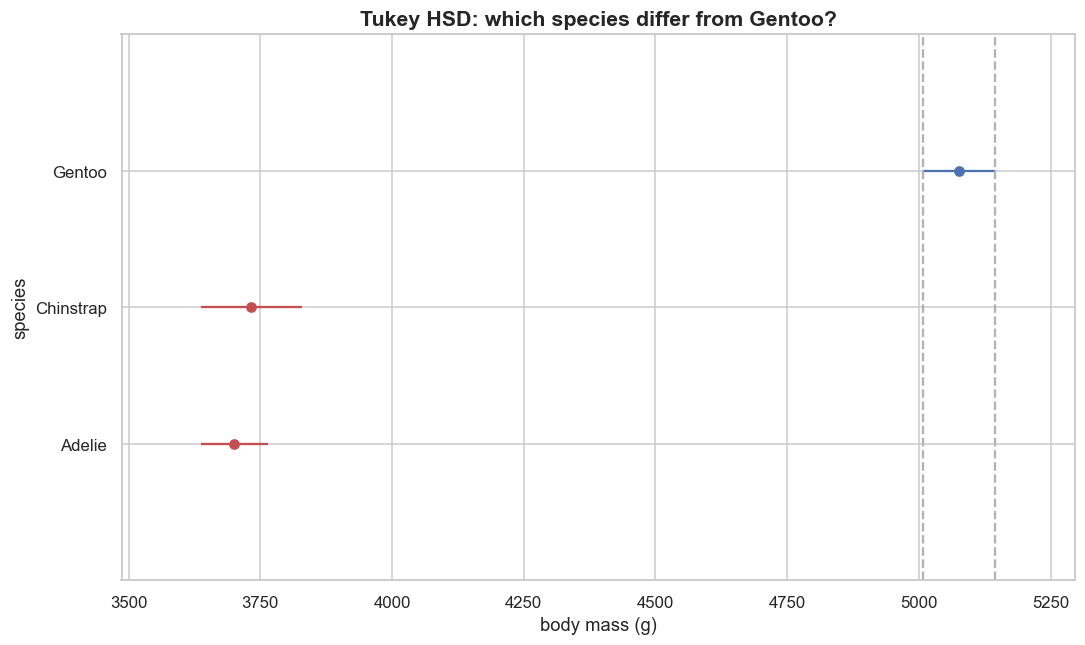

Bands that do NOT overlap Gentoo's vertical reference region differ significantly from Gentoo.


In [11]:
fig = tukey.plot_simultaneous(comparison_name='Gentoo', xlabel='body mass (g)', ylabel='species')
ax = plt.gca()
ax.set_title('Tukey HSD: which species differ from Gentoo?')
plt.tight_layout(); plt.show()
print('Bands that do NOT overlap Gentoo\'s vertical reference region differ significantly from Gentoo.')

## 7) The fine print: ANOVA's assumptions

Like every test, ANOVA trusts a few conditions. Worth knowing what they are and how to eyeball them:

1. **Independence** — observations don't influence each other (each penguin measured once,
   independently). This is about *how the data was collected*; no plot can rescue a violation, so it
   matters most.
2. **Roughly equal variances** across groups (sometimes called *homoscedasticity*). Classic ANOVA
   assumes each group has about the same spread. Compare the group SDs, or use **Levene's test**.
3. **Approximately normal residuals** — the leftover wobble *within* groups should be roughly
   bell-shaped. With large groups the Central Limit Theorem makes ANOVA forgiving of mild
   non-normality; a histogram or Q-Q plot is the quick check.

Let's run the two quantitative checks.

Group standard deviations (body mass, g):
  Adelie     n=151   SD =  458.6
  Chinstrap  n= 68   SD =  384.3
  Gentoo     n=123   SD =  504.1

Levene test for equal variances:  stat = 5.12,  p = 0.0064
  (p < 0.05 -> REJECT equal variances: the spreads differ more than chance would explain.)


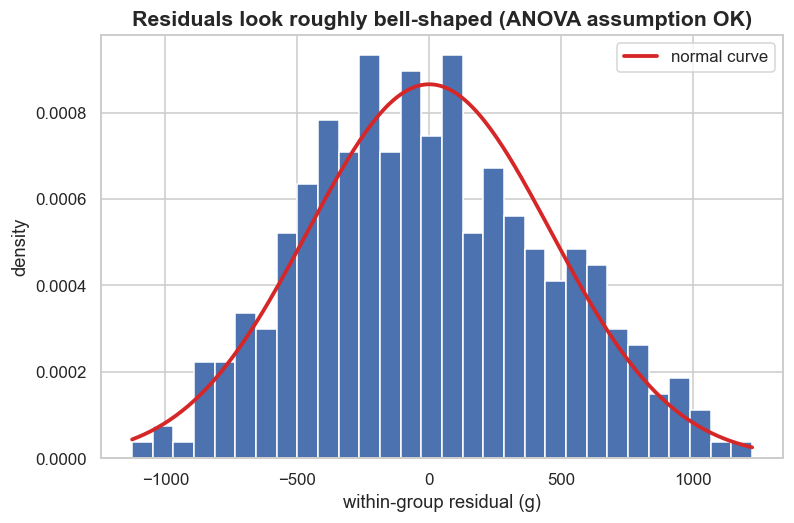

In [12]:
# Assumption 2: are the group spreads similar?
print('Group standard deviations (body mass, g):')
for s in species_order:
    g = penguins.loc[penguins['species'] == s, 'body_mass_g']
    print(f'  {s:<10} n={len(g):>3}   SD = {g.std(ddof=1):6.1f}')

lev_stat, lev_p = stats.levene(*groups)
print(f'\nLevene test for equal variances:  stat = {lev_stat:.2f},  p = {lev_p:.4f}')
verdict = ('p < 0.05 -> REJECT equal variances: the spreads differ more than chance would explain.'
           if lev_p < 0.05 else
           'p > 0.05 -> no strong evidence the spreads differ; equal-variance assumption is reasonable.')
print(f'  ({verdict})')

# Assumption 3: are the within-group residuals roughly normal?
residuals = np.concatenate([g - g.mean() for g in groups])
fig, ax = plt.subplots()
ax.hist(residuals, bins=30, color='#4c72b0', edgecolor='white', density=True)
xs = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, 0, residuals.std(ddof=1)), color='#d62728', lw=2.5,
        label='normal curve')
ax.set_xlabel('within-group residual (g)'); ax.set_ylabel('density')
ax.set_title('Residuals look roughly bell-shaped (ANOVA assumption OK)')
ax.legend(); plt.show()

The residuals are nicely bell-shaped, so the normality assumption is fine. The **equal-variance**
assumption, though, is **not** clean: Levene's test returns $p \approx 0.006$, which **rejects** equal
variances at $\alpha = 0.05$ — Gentoo wobble more (SD $\approx 504$ g) than Chinstrap (SD $\approx 384$
g), and the group sizes are unbalanced too, which makes unequal variance bite harder. This is exactly
the situation where plain one-way ANOVA's assumptions are shaky and you reach for **Welch's ANOVA**,
the robust alternative (just as Welch's t-test handles unequal variances for two groups). Reassuringly,
the omnibus signal here is so overwhelming — $F \approx 343$, Gentoo standing far apart — that the
"Gentoo vs the rest" conclusion holds either way; Welch would simply give a more honest p-value.

## Now you try

Predict first, then change a number and re-run:

1. **Feel the trap grow.** In section 2, raise the groups in the loop to include `20` or `25`. Before
   running, guess: at 20 identical groups, will the family-wise false-alarm rate be above or below
   90%? Then check.

2. **Re-roll the worlds.** Change `np.random.default_rng(0)` in the setup of section 2 to another
   number. Do the FWER percentages move much, or are they stable across seeds? (They should be
   stable — that's what makes it a *rate*.)

3. **A different measurement.** Add a cell and run ANOVA on `flipper_length_mm` across species instead
   of body mass:

       fl = penguins.dropna(subset=['flipper_length_mm'])
       gs = [fl.loc[fl['species'] == s, 'flipper_length_mm'] for s in species_order]
       print(stats.f_oneway(*gs))

   Is the F even bigger or smaller than for body mass? Then rerun Tukey HSD on flipper length — does
   the "Gentoo vs the rest" pattern still hold, or do more pairs separate?

4. **Make a difference vanish.** In a copy of the data, the ANOVA is huge because Gentoo stand apart.
   Drop Gentoo and test only Adelie vs Chinstrap with `stats.f_oneway`. Predict the p-value first —
   significant or not? — then confirm against the Tukey row for that pair.

## What you learned

- **Running many pairwise t-tests inflates the false-positive rate:** with several groups, the chance
  of at least one false "significant" climbs well past 5% even when nothing truly differs — you
  *simulated* this directly, and saw $1-(1-\alpha)^m$ act as an **upper bound** that the true
  (correlated) rate stays below.
- **One-way ANOVA** answers "**is any group mean different?**" with a single test at a controlled 5%
  error rate, so it sidesteps that trap.
- ANOVA works by splitting variation into **between-group** and **within-group** parts; the
  **F-statistic** $= MS_{\text{between}}/MS_{\text{within}}$ is large when group means are spread far
  apart relative to the noise inside groups.
- The **F-distribution** (with $k-1$ and $N-k$ degrees of freedom) is the reference for the p-value —
  and you rebuilt it from scratch by **shuffling labels**.
- $H_0$ is "all means equal"; a significant result means **at least one** differs — not which. With
  two groups, ANOVA is exactly the two-sample t-test ($F = t^2$).
- **Tukey HSD** is the post-hoc test that pinpoints *which* pairs differ while keeping the family-wise
  error at 5%; for these penguins it's **Gentoo vs the rest**, with Adelie and Chinstrap statistically
  tied.
- ANOVA assumes **independence**, **roughly equal variances**, and **approximately normal residuals**.
  For these penguins the residuals are bell-shaped, but **Levene's test rejects equal variances**
  ($p \approx 0.006$) — so the textbook alternative is **Welch's ANOVA**, even though the "Gentoo vs the
  rest" verdict is far too strong to be overturned by it.

---

**← Previous:** [Lesson 15: t-tests: one-sample, two-sample & paired](15-t-tests.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 17: Chi-square: goodness-of-fit & independence](17-chi-square.ipynb)

**Same idea, another way:**  [Another dataset →](16-anova~another-dataset.ipynb)  ·  [The code behind it →](16-anova~the-code.ipynb)